# Desafio 4: Relato de perda de faturamento na empresa em .txt

### Este desafio requer que sejam respondidas as seguintes 15 perguntas:

Perguntas que a diretoria quer respondidas
1. Quem são os melhores clientes? Como descobriram? Apresentem evidências.
2. Quem compra pouco? Vale a pena investir nesse grupo? Justifiquem.
3. Existe algum perfil inesperado na base de dados?
4. Há diferenças importantes entre as cidades?
5. Quais produtos deveriam receber maior investimento?
6. Existem clientes que parecem estar abandonando a empresa? Como perceberam isso?
7. Se o orçamento de marketing fosse de R$ 500.000, como ele seria distribuído?
8. Realizem uma segmentação utilizando a quantidade de grupos que considerarem ideal e justifiquem a escolha.
9. Dê um nome para todos os grupos encontrados.
10. Crie uma persona para cada grupo identificado.
11. Desenvolva uma estratégia diferente para cada grupo.
12. Construa pelo menos três gráficos que realmente auxiliem a diretoria na tomada de decisão.
13. Descubra pelo menos um insight que não foi solicitado pela empresa.
14. Critique a qualidade do banco de dados: quais informações estão faltando?
15. Descreva uma solução utilizando Inteligência Artificial que poderia ajudar a empresa.


Contexto
Vocês foram contratados pela empresa MegaStore. A empresa possui mais de 500 mil clientes e percebeu que as vendas cresceram pouco, os custos de marketing aumentaram e ninguém sabe exatamente quem são seus melhores clientes. A diretoria entregou a base de dados para a equipe de Ciência de Dados e espera recomendações baseadas em Data Mining.

Missão
Responder à pergunta: "Se vocês fossem os diretores desta empresa, quais decisões tomariam utilizando Data Mining?"

#### Parte Extra
Criem pelo menos cinco novas variáveis derivadas dos dados existentes (ex.: Índice de Fidelidade, Ticket Médio, Cliente VIP, Faixa Salarial, Nível de Risco, Frequência de Compra etc.). Expliquem a lógica de cada uma e utilizem essas novas variáveis na análise.


In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [2]:
df = pd.read_excel('Dataset_Data_Mining_Completo_5000.xlsx')

In [3]:
df = df.assign(
    Data_Compra=pd.to_datetime(df['Data_Compra'], format='%d/%m/%Y'),
    Dia_da_Semana=lambda x: x['Data_Compra'].dt.day_name(),
    Cancelou=lambda x: x['Cancelou'].map({'Sim': 1, 'Não': 0}),
    Fraude=lambda x: x['Fraude'].map({'Sim': 1, 'Não': 0}),
    Cupom=lambda x: x['Cupom'].map({'Sim': 1, 'Não': 0}),
    Programa_Fidelidade=lambda x: x['Programa_Fidelidade'].map({'Sim': 1, 'Não': 0}),
    Faixa_Etaria=lambda x: pd.cut(x['Idade'], bins=[0, 25, 35, 45, 55, 100], labels=['Até 25', '26-35', '36-45', '46-55', '55+']),
    Faixa_Desconto=lambda x: pd.cut(x['Desconto_%'], bins=[0, 10, 20, 30, 50, 100], right=False)
)

In [4]:
df.columns

Index(['ID_Compra', 'ID_Cliente', 'Idade', 'Sexo', 'Estado_Civil', 'Cidade',
       'Regiao', 'Renda_Mensal', 'Tempo_Cliente_Anos', 'Canal', 'Produto',
       'Categoria', 'Quantidade', 'Valor_Unitario', 'Desconto_%',
       'Valor_Total', 'Forma_Pagamento', 'Cupom', 'Programa_Fidelidade',
       'Avaliacao', 'Cancelou', 'Fraude', 'Mes', 'Data_Compra',
       'Dia_da_Semana', 'Faixa_Etaria', 'Faixa_Desconto'],
      dtype='str')

In [ ]:
df["Grupo_Clientes"] = ((df["Fraude"] == 1) | (df["Cancelou"] == 1)).astype(int)

In [27]:
x = df[['Renda_Mensal', 'Valor_Total', 'Quantidade', 'Tempo_Cliente_Anos', 'Grupo_Clientes']]

In [28]:
df[df['Cancelou'] == 0].sort_values(by='Valor_Total', ascending=False).head(10)

,ID_Compra,ID_Cliente,Idade,Sexo,Estado_Civil,Cidade,Regiao,Renda_Mensal,Tempo_Cliente_Anos,Canal,...,Programa_Fidelidade,Avaliacao,Cancelou,Fraude,Mes,Data_Compra,Dia_da_Semana,Faixa_Etaria,Faixa_Desconto,Grupo_Clientes
3071,3072,C0546,42,M,Solteiro,Belém,Norte,21712,5,Site,...,1,4,0,0,September,2025-09-19,Friday,36-45,"[0, 10)",0
3375,3376,C0214,37,F,Solteiro,Fortaleza,Nordeste,9647,12,App,...,1,5,0,1,June,2025-06-08,Sunday,36-45,"[0, 10)",1
694,695,C0714,48,M,Divorciado,Belém,Norte,20084,6,App,...,0,4,0,0,July,2025-07-19,Saturday,46-55,"[0, 10)",0
3050,3051,C0621,68,M,Solteiro,Fortaleza,Nordeste,6085,10,App,...,1,5,0,0,August,2025-08-27,Wednesday,55+,"[0, 10)",0
1413,1414,C0056,19,M,Solteiro,Manaus,Norte,11697,14,App,...,1,3,0,0,February,2025-02-26,Wednesday,Até 25,"[0, 10)",0
1424,1425,C0622,47,F,Solteiro,Manaus,Norte,18599,2,Site,...,0,3,0,0,May,2025-05-06,Tuesday,46-55,"[0, 10)",0
1868,1869,C0297,52,M,Solteiro,Brasília,Centro-Oeste,9528,4,App,...,0,4,0,0,August,2025-08-29,Friday,46-55,"[0, 10)",0
1141,1142,C0500,29,M,Casado,Manaus,Norte,21221,5,Loja,...,1,5,0,0,November,2025-11-12,Wednesday,26-35,"[0, 10)",0
1744,1745,C0580,19,M,Casado,Manaus,Norte,8096,11,Loja,...,0,5,0,0,December,2025-12-01,Monday,Até 25,"[0, 10)",0
4565,4566,C0196,43,F,Casado,Recife,Nordeste,5770,7,App,...,0,5,0,0,April,2025-04-23,Wednesday,36-45,"[0, 10)",0


In [18]:
y = df[['ID_Cliente']]

In [19]:
melhor_cliente = DecisionTreeClassifier(random_state=42, max_depth=4)

In [20]:
melhor_cliente.fit(x, y)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

[Text(0.5, 0.9, 'Renda_Mensal <= 6343.5\ngini = 0.999\nsamples = 5000\nvalue = [12.0, 9.0, 9.0, 9.0, 5.0, 7.0, 8.0, 7.0, 10.0, 5.0\n6.0, 5.0, 6.0, 10.0, 7.0, 8.0, 7.0, 7.0, 7.0, 7.0\n5.0, 11.0, 4.0, 5.0, 4.0, 5.0, 10.0, 7.0, 3.0, 6.0\n2.0, 8.0, 3.0, 7.0, 6.0, 8.0, 9.0, 6.0, 6.0, 8.0\n8.0, 7.0, 5.0, 6.0, 9.0, 7.0, 6.0, 4.0, 8.0, 2.0\n7.0, 1.0, 5.0, 5.0, 7.0, 8.0, 4.0, 7.0, 2.0, 2.0\n5.0, 6.0, 8.0, 10.0, 10.0, 4.0, 7.0, 5.0, 1.0, 9.0\n8.0, 7.0, 9.0, 6.0, 4.0, 8.0, 3.0, 6.0, 1.0, 5.0\n9.0, 8.0, 11.0, 11.0, 4.0, 13.0, 7.0, 4.0, 5.0, 8.0\n2.0, 4.0, 4.0, 7.0, 8.0, 7.0, 10.0, 13.0, 2.0, 3.0\n7.0, 5.0, 5.0, 2.0, 10.0, 6.0, 10.0, 5.0, 10.0, 8.0\n5.0, 7.0, 5.0, 9.0, 10.0, 7.0, 8.0, 3.0, 7.0, 9.0\n6.0, 12.0, 6.0, 4.0, 8.0, 9.0, 7.0, 6.0, 4.0, 9.0\n8.0, 7.0, 10.0, 7.0, 7.0, 4.0, 4.0, 3.0, 4.0, 6.0\n5.0, 4.0, 2.0, 4.0, 6.0, 2.0, 5.0, 3.0, 8.0, 9.0\n8.0, 6.0, 3.0, 3.0, 11.0, 8.0, 8.0, 9.0, 7.0, 7.0\n8.0, 5.0, 4.0, 9.0, 8.0, 10.0, 6.0, 8.0, 4.0, 11.0\n4.0, 8.0, 6.0, 5.0, 6.0, 10.0, 6.0, 3.0, 7.0, 7.0

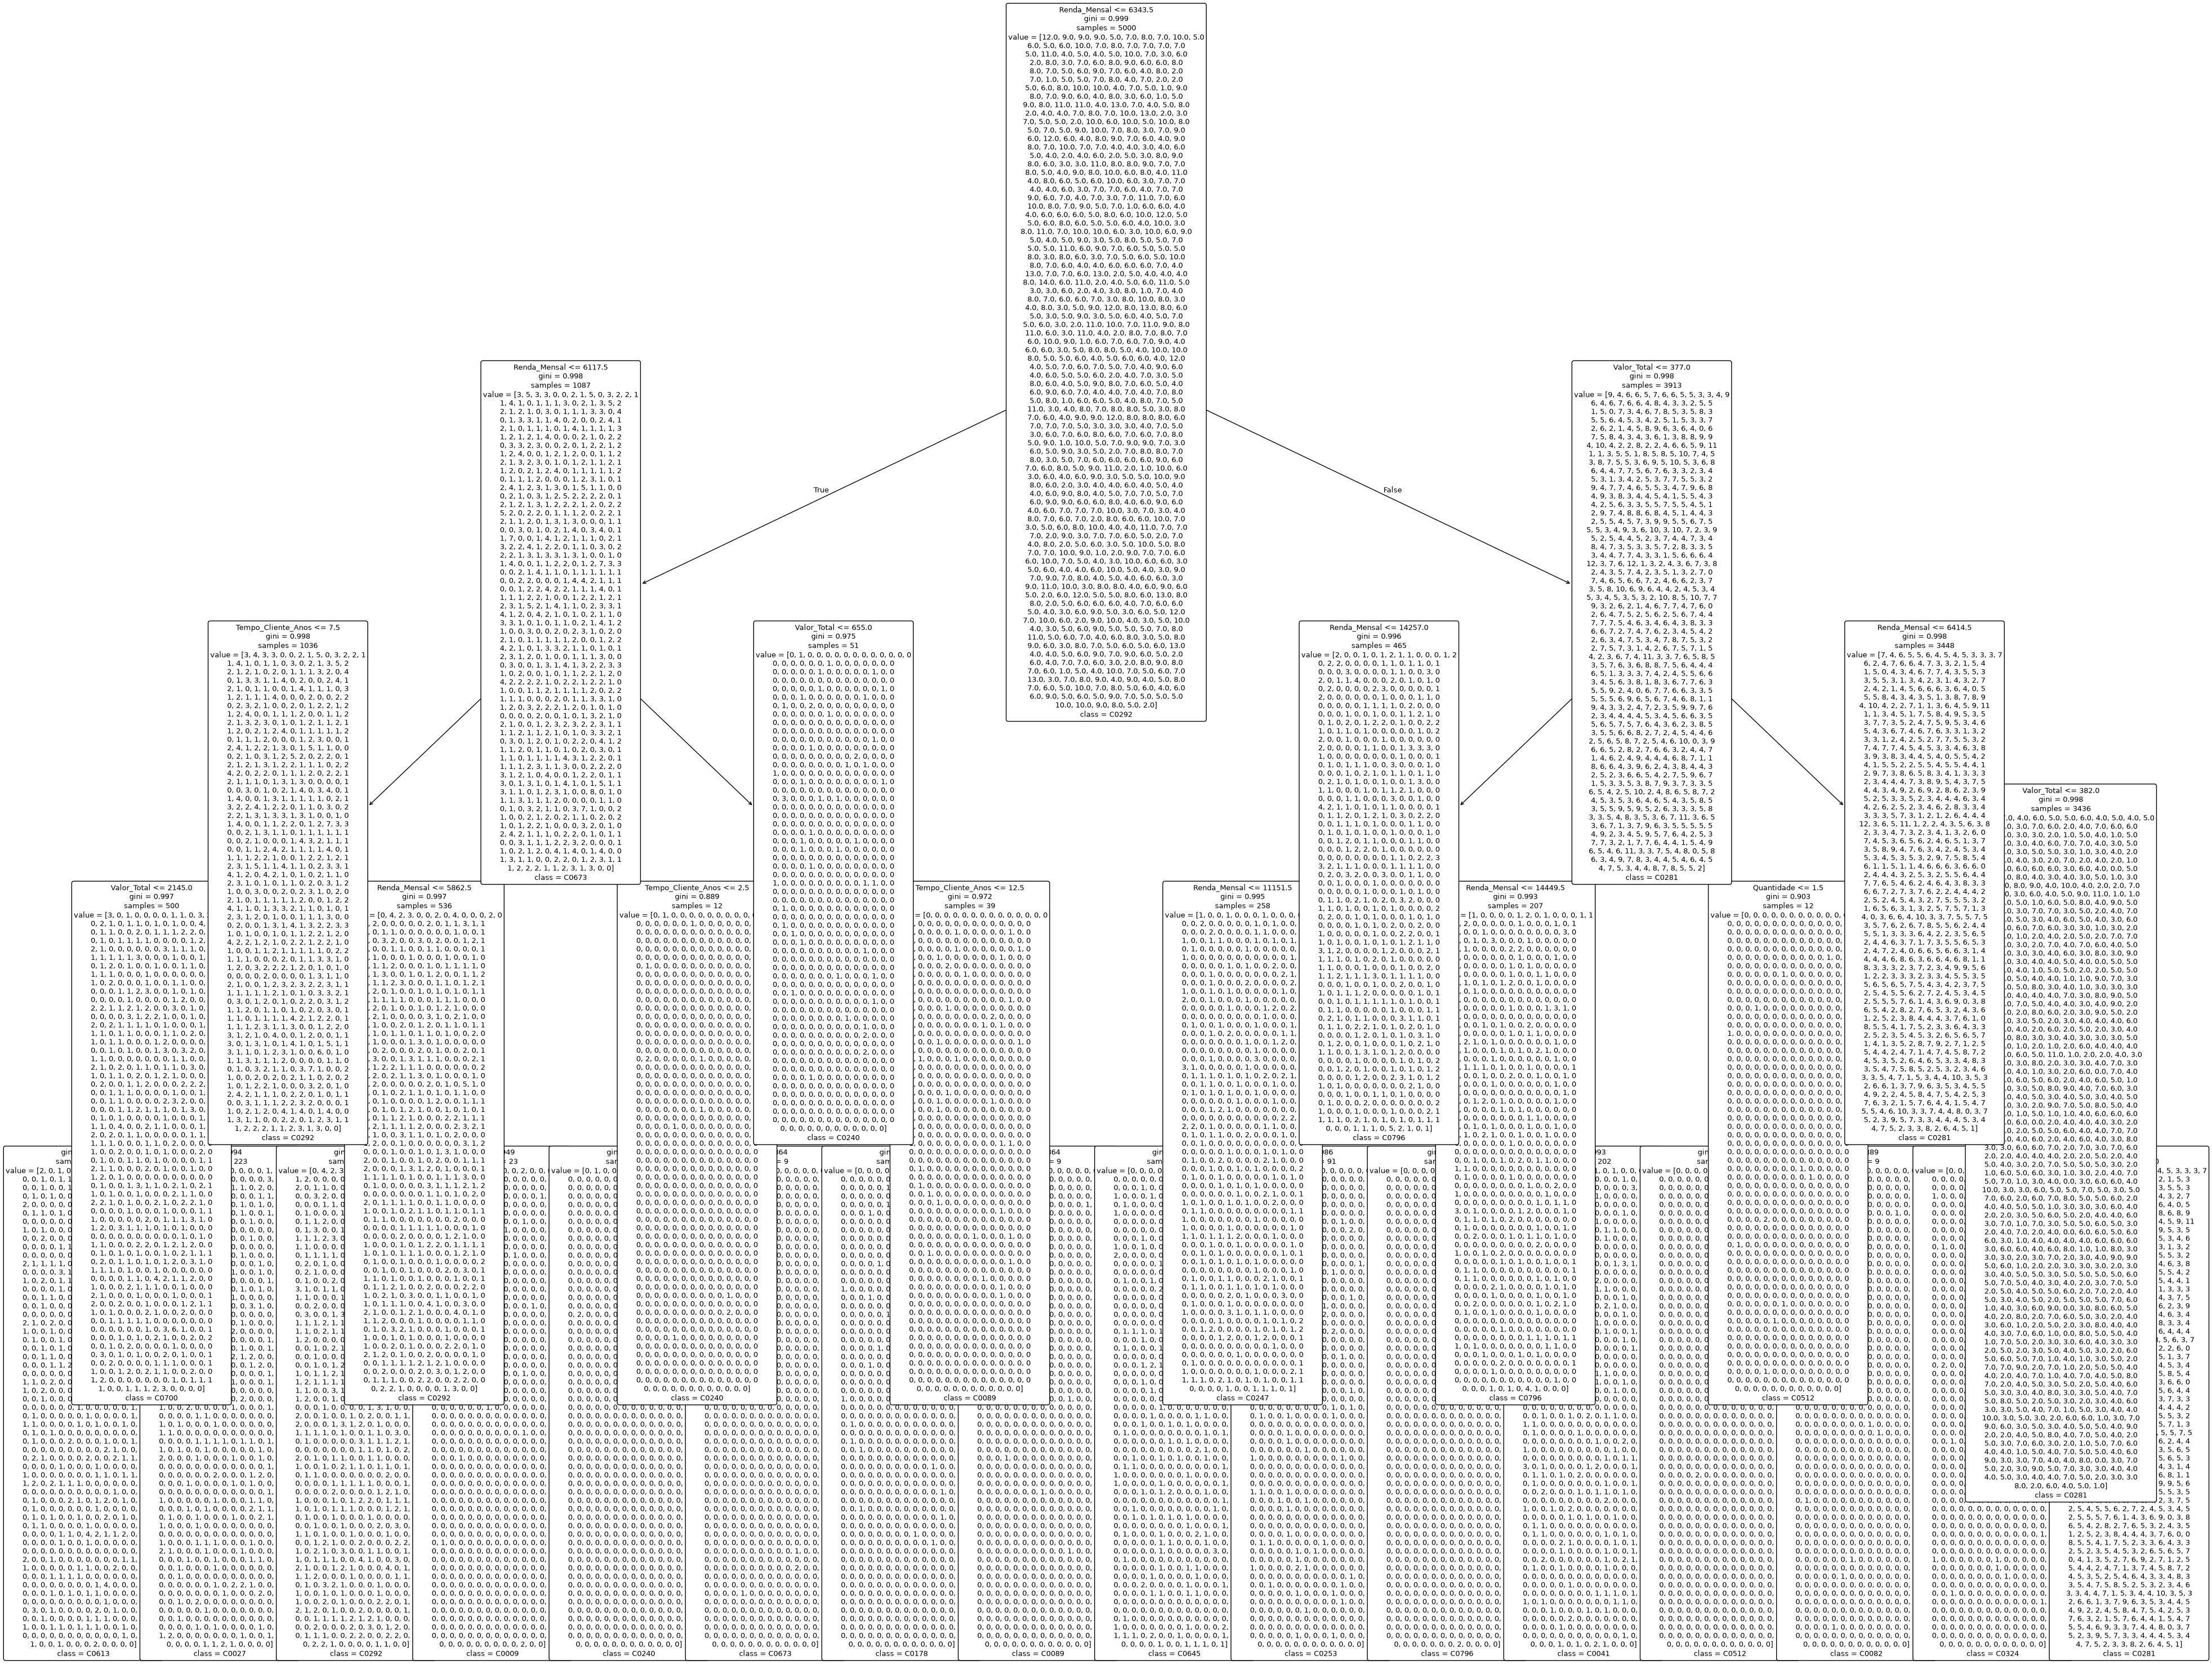

In [26]:
plt.figure(figsize=(50, 30))

plot_tree(
    melhor_cliente,
    feature_names=x.columns,
    class_names=melhor_cliente.classes_,
    rounded=True,
    fontsize=9
    )

In [ ]:
df[df['Renda_Mensal'] > 6117.5].sort_values(by='Valor_Total', ascending=False).where(df['Tempo_Cliente_Anos'] >= 7 &)

,ID_Compra,ID_Cliente,Idade,Sexo,Estado_Civil,Cidade,Regiao,Renda_Mensal,Tempo_Cliente_Anos,Canal,...,Programa_Fidelidade,Avaliacao,Cancelou,Fraude,Mes,Data_Compra,Dia_da_Semana,Faixa_Etaria,Faixa_Desconto,Grupo_Clientes
1744,1745.0,C0580,19.0,M,Casado,Manaus,Norte,8096.0,11.0,Loja,...,0.0,5.0,0.0,0.0,December,2025-12-01,Monday,Até 25,"[0.0, 10.0)",0.0
3648,3649.0,C0541,34.0,F,Casado,Manaus,Norte,14795.0,12.0,App,...,1.0,4.0,0.0,0.0,January,2025-01-12,Sunday,26-35,"[0.0, 10.0)",0.0
551,552.0,C0218,28.0,M,Divorciado,Brasília,Centro-Oeste,10502.0,10.0,App,...,1.0,5.0,0.0,0.0,January,2025-01-19,Sunday,26-35,"[0.0, 10.0)",0.0
832,833.0,C0534,22.0,M,Solteiro,Manaus,Norte,21871.0,13.0,Loja,...,1.0,3.0,0.0,0.0,September,2025-09-02,Tuesday,Até 25,"[0.0, 10.0)",0.0
4198,4199.0,C0692,32.0,F,Divorciado,Belém,Norte,21230.0,10.0,Loja,...,0.0,3.0,0.0,0.0,June,2025-06-23,Monday,26-35,"[0.0, 10.0)",0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN
1294,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN
206,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN
4289,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN
